# Windy Gridworld — SARSA

On‑policy TD control (SARSA) on the windy gridworld from Sutton & Barto
Example 6.5.  ε = 0.1, α = 0.5, undiscounted, reward = −1 per step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

In [2]:
class WindyGridworld:
    def __init__(self):
        self.rows = 7
        self.cols = 10
        self.start = (3, 0)
        self.goal = (3, 7)
        self.wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
        self.actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # R, L, U, D

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        row, col = self.state
        dr, dc = self.actions[action]

        row += dr
        col += dc
        row -= self.wind[self.state[1]]  # wind on column *before* the move

        row = max(0, min(self.rows - 1, row))
        col = max(0, min(self.cols - 1, col))

        self.state = (row, col)
        done = self.state == self.goal
        return self.state, -1, done

In [3]:
def sarsa(alpha=0.5, epsilon=0.1, n_episodes=200):
    env = WindyGridworld()
    Q = np.zeros((env.rows, env.cols, 4))

    episode_lengths = []
    cum_steps = 0
    cum_steps_list = []

    for ep in range(n_episodes):
        state = env.reset()

        if np.random.random() < epsilon:
            action = np.random.randint(4)
        else:
            action = np.argmax(Q[state[0], state[1]])

        steps = 0
        done = False
        while not done:
            next_state, reward, done = env.step(action)

            if np.random.random() < epsilon:
                next_action = np.random.randint(4)
            else:
                next_action = np.argmax(Q[next_state[0], next_state[1]])

            Q[state[0], state[1], action] += alpha * (reward + Q[next_state[0], next_state[1], next_action] - Q[state[0], state[1], action])

            state = next_state
            action = next_action
            steps += 1

        episode_lengths.append(steps)
        cum_steps += steps
        cum_steps_list.append(cum_steps)

    return Q, np.array(episode_lengths), np.array(cum_steps_list)

Total time steps: 8939
Last 10 episodes average length: 22.4  (minimum: 15)
Optimal path: 15 steps


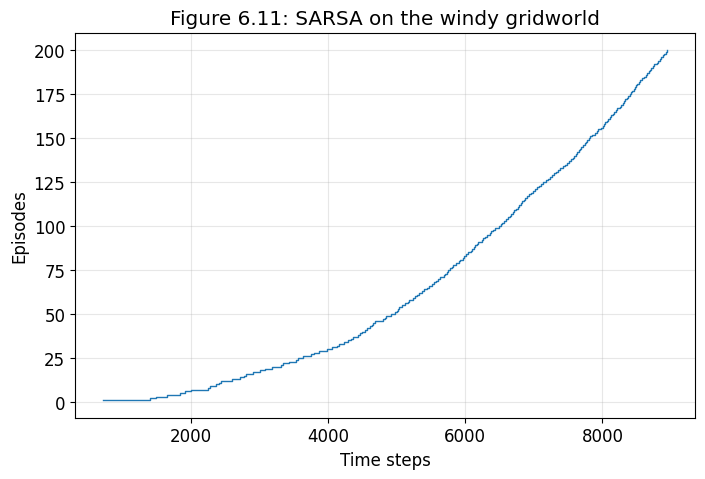

In [4]:
# ── Run SARSA and plot Figure 6.11 ──
Q, ep_lens, cum_steps = sarsa(alpha=0.5, epsilon=0.1, n_episodes=200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cum_steps, np.arange(1, len(cum_steps) + 1), linewidth=1, drawstyle="steps-post")
ax.set_xlabel("Time steps")
ax.set_ylabel("Episodes")
ax.set_title("Figure 6.11: SARSA on the windy gridworld")
ax.grid(True, alpha=0.3)

print(f"Total time steps: {cum_steps[-1]}")
print(f"Last 10 episodes average length: {ep_lens[-10:].mean():.1f}  (minimum: {ep_lens.min()})")
print(f"Optimal path: 15 steps")
plt.show()

Greedy path length: 15 steps
Path: (3,0) → (3,1) → (3,2) → (3,3) → (2,4) → (1,5) → (0,6) → (0,7) → (0,8) → (0,9) → (1,9) → (2,9) → (3,9) → (4,9) → (4,8) → (3,7)


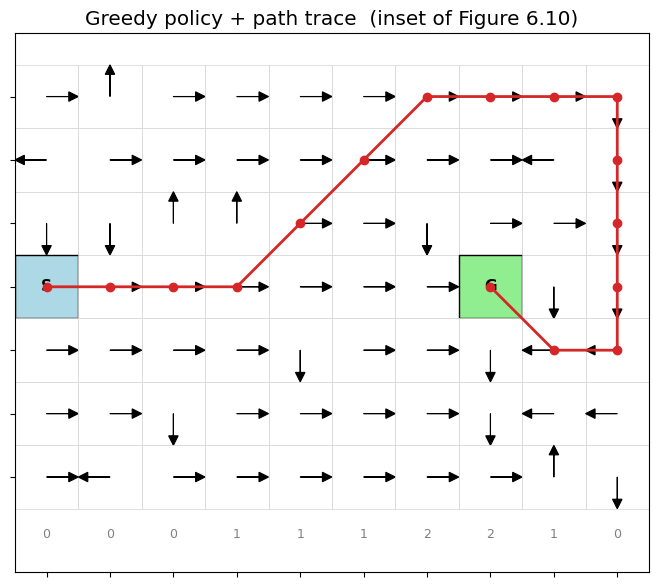

In [5]:
# ── Greedy path trace ──
env = WindyGridworld()
state = env.reset()
path = [state]
done = False
while not done:
    a = np.argmax(Q[state[0], state[1]])
    state, _, done = env.step(a)
    path.append(state)

path_rows = [p[0] for p in path]
path_cols = [p[1] for p in path]
print(f"Greedy path length: {len(path) - 1} steps")
print("Path:", " → ".join(f"({r},{c})" for r, c in path))

# ── Greedy policy + path ──
action_arrows = {0: (0.35, 0), 1: (-0.35, 0), 2: (0, -0.35), 3: (0, 0.35)}

fig, ax = plt.subplots(figsize=(10, 7))

for r in range(7):
    for c in range(10):
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                   facecolor="white", edgecolor="lightgray", linewidth=0.5))
        if (r, c) == (3, 0):
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor="lightblue", edgecolor="black"))
            ax.text(c, r, "S", ha="center", va="center", fontweight="bold", fontsize=11)
        elif (r, c) == (3, 7):
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       facecolor="lightgreen", edgecolor="black"))
            ax.text(c, r, "G", ha="center", va="center", fontweight="bold", fontsize=11)
        else:
            best_a = np.argmax(Q[r, c])
            dx, dy = action_arrows[best_a]
            ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.15,
                     fc="black", ec="black", linewidth=0.8)

# Greedy path trace
ax.plot(path_cols, path_rows, "o-", color="C3", linewidth=2, markersize=6, zorder=5)

# Wind strength below each column
for c, w in enumerate([0, 0, 0, 1, 1, 1, 2, 2, 1, 0]):
    ax.text(c, 7.0, str(w), ha="center", va="bottom", fontsize=9, color="gray")

ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-1.0, 7.5)
ax.set_xticks(range(10))
ax.set_yticks(range(7))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title("Greedy policy + path trace  (inset of Figure 6.10)")
plt.show()